# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

In [1]:
!git clone https://github.com/Tiendung3tzz/K4-DAY02-TongTranTienDung-2A202602791.git

Cloning into 'K4-DAY02-TongTranTienDung-2A202602791'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 74 (delta 9), reused 4 (delta 4), pack-reused 53 (from 2)
Receiving objects: 100% (74/74), 113.21 KiB | 1.69 MiB/s, done.
Resolving deltas: 100% (22/22), done.


## 0. Cài đặt môi trường

In [2]:
# Run on Kaggle. Upload or clone this repo first; data is supplied separately via Kaggle Input.
%pip -q install timm thop matplotlib openpyxl
import sys, os, platform
import numpy as np, pandas as pd, torch, timm
from pathlib import Path

REPO_DIR = Path("/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791")
CODE_DIR = REPO_DIR / "submissions/2A202602791_Tong_Tran_Tien_Dung/code"
assert CODE_DIR.is_dir(), f"Set REPO_DIR to the uploaded/cloned repository: {CODE_DIR}"
sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(CODE_DIR))
import dataset, model, losses, train
print("python", platform.python_version(), "| torch", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Note: you may need to restart the kernel to use updated packages.
python 3.13.15 | torch 2.11.0+cu128
GPU: Tesla T4


### Dữ liệu Kaggle Input
Gắn dataset ảnh và bốn file CSV vào notebook. Đặt hai đường dẫn bên dưới đến thư mục chứa ảnh và thư mục chứa CSV. Notebook không tự tải dữ liệu.


In [3]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

20160928-140314-0.jpg
20160928-140337-0.jpg
20160928-140731-0.jpg
20160928-140747-0.jpg
20160928-141107-0.jpg
20160928-141135-0.jpg
20160928-141355-0.jpg
20160928-141421-0.jpg
20160928-141437-0.jpg
20160928-142056-0.jpg
ls: write error: Broken pipe
total 1828
drwxr-xr-x 2 root root   4096 Oct  5 01:33 .
drwxr-xr-x 3 root root 839680 Oct  5 01:33 ..
-rw-r--r-- 1 root root 598898 Oct  5 01:33 labels.csv
-rw-r--r-- 1 root root  84183 Oct  5 01:33 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  5 01:33 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  5 01:33 val_subset0.csv


In [4]:
# Edit these two paths to match your Kaggle Input folder.
IMAGES_DIR = Path("/kaggle/input/datasets/quchuy2k4/images")
LABELS_DIR = Path("/kaggle/working/data/labels")
assert IMAGES_DIR.is_dir(), f"Image directory not found: {IMAGES_DIR}"
# assert LABELS_DIR.is_dir(), f"Labels directory not found: {LABELS_DIR}"
print("Image examples:", [p.name for p in list(IMAGES_DIR.glob("*.jpg"))[:5]])
print("CSV files:", sorted(p.name for p in LABELS_DIR.glob("*subset0.csv")))

Image examples: ['20171219-112552-3.jpg', '20180112-091948-2.jpg', '20170217-145044-0.jpg', '20170217-113555-0.jpg', '20170217-111344-0.jpg']
CSV files: ['test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


In [5]:
# Confirm paths before running the split audit.
print("IMAGES_DIR =", IMAGES_DIR)
print("LABELS_DIR =", LABELS_DIR)

IMAGES_DIR = /kaggle/input/datasets/quchuy2k4/images
LABELS_DIR = /kaggle/working/data/labels


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

Split audit: {'counts': {'train': 10501, 'val': 3501, 'test': 3507}, 'ratios': {'train': 0.5997487006682277, 'val': 0.19995430921240506, 'test': 0.2002969901193672}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union_count': 17509, 'missing_images': 0}


,train,val,test
Chinee Apple,675,225,226
Lantana,637,213,213
Parkinsonia,618,206,207
Parthenium,613,204,205
Prickly Acacia,637,212,213
Rubber Vine,605,202,202
Siam Weed,644,215,215
Snake Weed,609,203,204
Negatives,5463,1821,1822


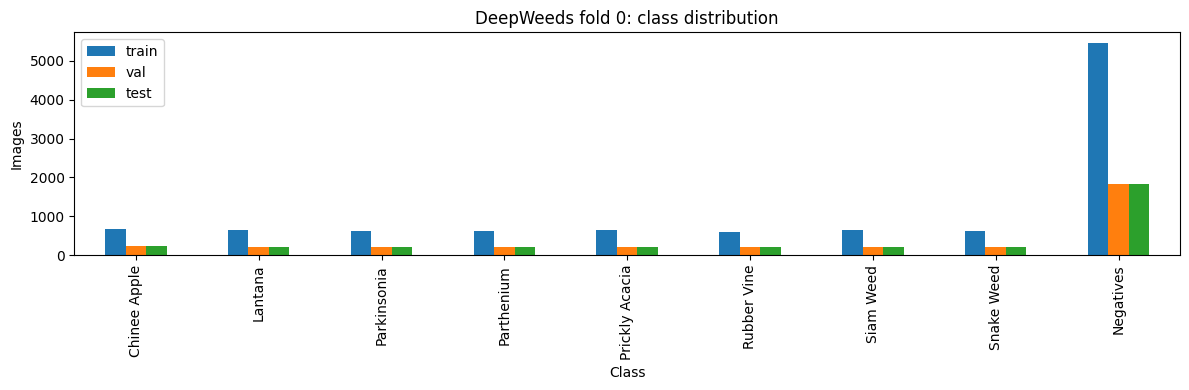

Largest/smallest class ratio: 9.02
Paper reference only: Negative 9,106; weed classes 1,009–1,125 each.
Your actual totals: {'Chinee Apple': 1126, 'Lantana': 1063, 'Parkinsonia': 1031, 'Parthenium': 1022, 'Prickly Acacia': 1062, 'Rubber Vine': 1009, 'Siam Weed': 1074, 'Snake Weed': 1016, 'Negatives': 9106}


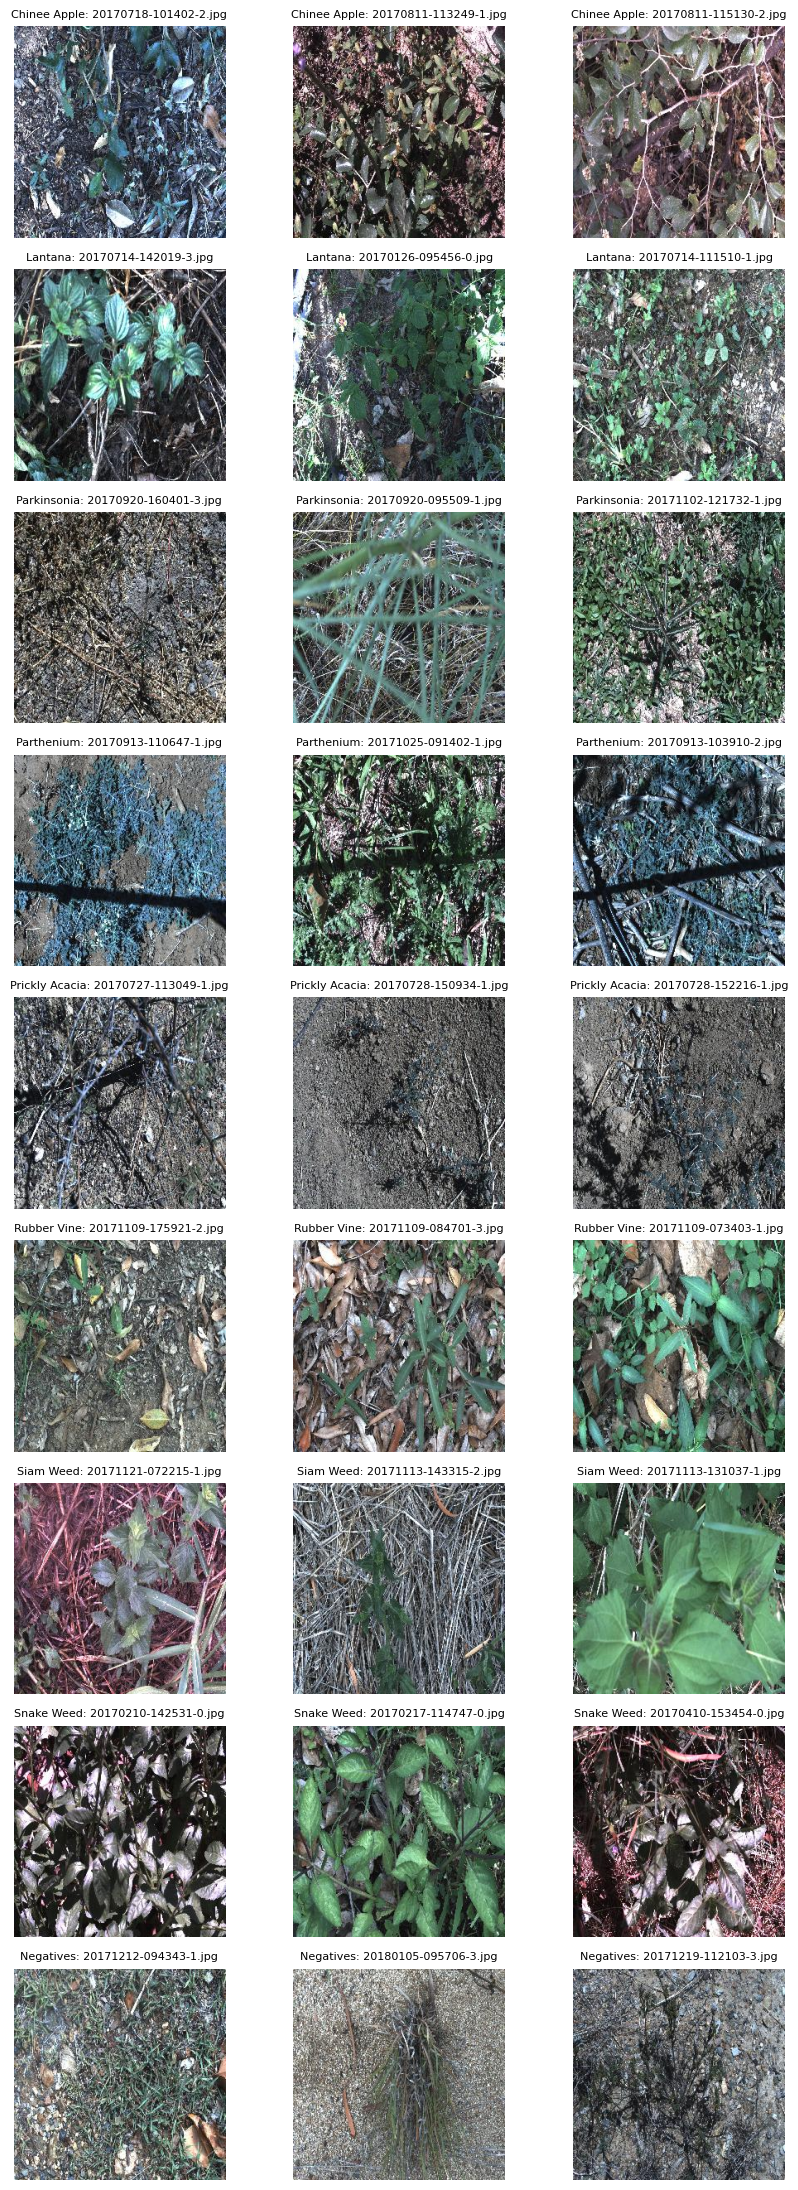

Sample (width, height, channels) counts:
(256, 256, 3)    100
Name: count, dtype: int64


In [6]:
# Official fold 0 only. check_split aborts on overlap, missing files or wrong total.
import matplotlib.pyplot as plt

train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_report = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
counts = pd.DataFrame(split_report["per_class"]).reindex(range(dataset.NUM_CLASSES))
counts.index = dataset.CLASS_NAMES
display(counts)
ax = counts.plot.bar(figsize=(12, 4), title="DeepWeeds fold 0: class distribution")
ax.set(xlabel="Class", ylabel="Images")
plt.tight_layout()
plt.show()
totals = counts.sum(axis=1)
print("Largest/smallest class ratio:", round(totals.max() / totals.min(), 2))
print("Paper reference only: Negative 9,106; weed classes 1,009–1,125 each.")
print("Your actual totals:", totals.to_dict())

# Three sample images per class, from TRAIN only.
from PIL import Image
fig, axes = plt.subplots(dataset.NUM_CLASSES, 3, figsize=(9, 22))
for label in range(dataset.NUM_CLASSES):
    rows = train_df.loc[train_df["Label"] == label, "Filename"].head(3)
    assert len(rows) == 3, f"Class {label} has fewer than three training images"
    for col, filename in enumerate(rows):
        with Image.open(IMAGES_DIR / filename) as image:
            axes[label, col].imshow(image.convert("RGB"))
        axes[label, col].set_title(f"{dataset.CLASS_NAMES[label]}: {filename}", fontsize=8)
        axes[label, col].axis("off")
plt.tight_layout()
plt.show()

# Check sizes and channels on a deterministic sample of 100 TRAIN images.
sample = train_df.sample(n=min(100, len(train_df)), random_state=0)
shapes = []
for filename in sample["Filename"]:
    with Image.open(IMAGES_DIR / filename) as image:
        shapes.append((image.width, image.height, len(image.getbands())))
print("Sample (width, height, channels) counts:")
print(pd.Series(shapes).value_counts())

Initial CE: 2.218043327331543 ; ln(9): 2.1972245773362196
Difference from ln(9) is diagnostic, not a strict assertion.


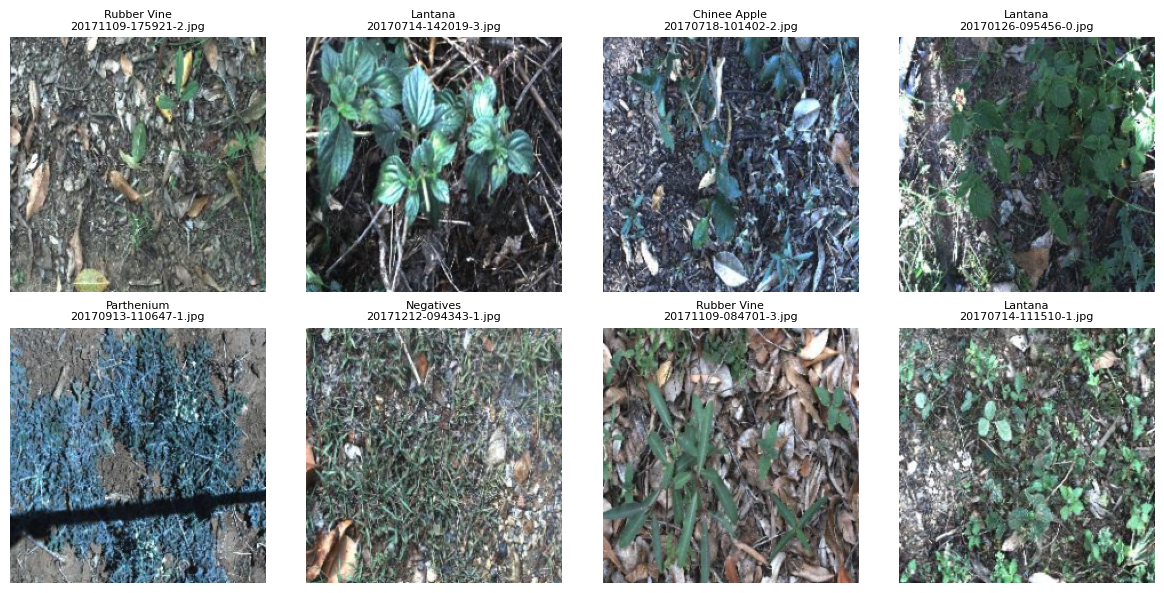

Training mode: True
Tiny-batch overfit: {'steps': 11, 'train_loss': 0.04095357656478882, 'eval_loss': 0.857761025428772}
Evaluation mode: True


In [7]:
# Pipeline smoke check. It uses a tiny fixed TRAIN batch, never val or test for optimization.
train.set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_df = train_df.head(8)
plain = dataset.DeepWeedsDataset(sample_df, IMAGES_DIR, dataset.build_transforms(False))
x = torch.stack([plain[i][0] for i in range(4)]).to(device)
y = torch.tensor([plain[i][1] for i in range(4)], device=device)
net = model.build_model("resnet18", pretrained=False, init="scratch").to(device)
criterion = losses.build_criterion("ce")
net.eval()
with torch.inference_mode():
    initial_loss = criterion(net(x), y).item()
print("Initial CE:", initial_loss, "; ln(9):", np.log(9))
print("Difference from ln(9) is diagnostic, not a strict assertion.")

# Visualize augmented TRAIN samples after denormalization.
aug_ds = dataset.DeepWeedsDataset(sample_df, IMAGES_DIR, dataset.build_transforms(True, 224, "basic"))
mean = torch.tensor(dataset.IMAGENET_MEAN)[:, None, None]
std = torch.tensor(dataset.IMAGENET_STD)[:, None, None]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    image, label, filename = aug_ds[i]
    ax.imshow((image * std + mean).clamp(0, 1).permute(1, 2, 0))
    ax.set_title(f"{dataset.CLASS_NAMES[label]}\n{filename}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Fit the exact same tiny batch until nearly zero loss; stop early when it succeeds.
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=0)
net.train()
print("Training mode:", net.training)
for step in range(250):
    optimizer.zero_grad(set_to_none=True)
    loss = criterion(net(x), y)
    loss.backward()
    optimizer.step()
    if loss.item() < 0.05:
        break
net.eval()
with torch.inference_mode():
    final_loss = criterion(net(x), y).item()
print("Tiny-batch overfit:", {"steps": step + 1, "train_loss": loss.item(), "eval_loss": final_loss})
assert loss.item() < 0.05, "Tiny batch did not overfit; inspect data, optimizer and model"
print("Evaluation mode:", not net.training)

## Bước 1 — So sánh backbone (ít nhất 5)

Chạy cùng cấu hình T00, fold 0 và seed 0. Chỉ thay `exp_id` và `backbone`. Mỗi kết quả được ghi ngay vào sheet **Backbones** để có thể tiếp tục sau khi Kaggle ngắt phiên. Không chạy test ở bước này. Số đo độ trễ là forward batch 1, có warmup và đồng bộ CUDA, không tính tiền xử lý.

Split audit: {'counts': {'train': 10501, 'val': 3501, 'test': 3507}, 'ratios': {'train': 0.5997487006682277, 'val': 0.19995430921240506, 'test': 0.2002969901193672}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union_count': 17509, 'missing_images': 0}


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

B01 seed=0 epoch=1: {'epoch': 1, 'train_loss': 1.6263840343894027, 'lr': 0.0001, 'val_loss': 1.2275158653120353, 'macro_f1_val': 0.2360038038690062, 'top1_val': 0.570694087403599, 'train_seconds': 129.66087647899985, 'epoch_seconds': 172.21377138699995}
B01 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.8855658918619156, 'lr': 9.797464868072488e-05, 'val_loss': 0.7514297307576155, 'macro_f1_val': 0.5970436726692794, 'top1_val': 0.7355041416738075, 'train_seconds': 48.97115441699998, 'epoch_seconds': 61.73864617300001}
B01 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.5785084486734576, 'lr': 9.206267664155907e-05, 'val_loss': 0.6055964291248959, 'macro_f1_val': 0.6941886298726694, 'top1_val': 0.7897743501856612, 'train_seconds': 46.43324921399994, 'epoch_seconds': 59.41663328300001}
B01 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.4420955123879561, 'lr': 8.274303669726426e-05, 'val_loss': 0.5484964086375418, 'macro_f1_val': 0.7323430092605089, 'top1_val': 0.8117680662667809, 'train_seconds

,exp_id,backbone,weight_tag,timm_version,params_m,gmacs_thop,img_size,epochs,seed,macro_f1_val,top1_val,train_seconds_per_epoch,latency_batch1_p50_ms,latency_batch1_p95_ms,latency_dtype,latency_device,curve,note
0,B01,resnet50,timm/resnet50.a1_in1k,1.0.29,23.526473,4.131713,224,12,0,0.792046,0.852614,54.366179,7.403682,7.976612,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only


...

B05 seed=0 epoch=1: {'epoch': 1, 'train_loss': 2.017157296581966, 'lr': 0.0001, 'val_loss': 1.284074540275807, 'macro_f1_val': 0.4721726151734919, 'top1_val': 0.5901171093973151, 'train_seconds': 39.40524901400022, 'epoch_seconds': 45.80327227499947}
B05 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.6482416846584983, 'lr': 9.797464868072488e-05, 'val_loss': 0.9116713599932599, 'macro_f1_val': 0.610513912765873, 'top1_val': 0.7117966295344187, 'train_seconds': 30.05016803700073, 'epoch_seconds': 36.25775274600073}
B05 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.3719925908598958, 'lr': 9.206267664155907e-05, 'val_loss': 0.7504508464855999, 'macro_f1_val': 0.6808903455159445, 'top1_val': 0.7674950014281634, 'train_seconds': 28.915065999000035, 'epoch_seconds': 35.08312183399994}
B05 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.2582279946655035, 'lr': 8.274303669726426e-05, 'val_loss': 0.6213101626668307, 'macro_f1_val': 0.7356921556131386, 'top1_val': 0.8063410454155956, 'train_seconds': 

,exp_id,backbone,weight_tag,timm_version,params_m,gmacs_thop,img_size,epochs,seed,macro_f1_val,top1_val,train_seconds_per_epoch,latency_batch1_p50_ms,latency_batch1_p95_ms,latency_dtype,latency_device,curve,note
4,B05,efficientnet_b0,timm/efficientnet_b0.ra_in1k,1.0.29,4.019077,0.38461,224,12,0,0.798559,0.852042,30.468323,10.391495,11.016293,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only


,exp_id,backbone,weight_tag,timm_version,params_m,gmacs_thop,img_size,epochs,seed,macro_f1_val,top1_val,train_seconds_per_epoch,latency_batch1_p50_ms,latency_batch1_p95_ms,latency_dtype,latency_device,curve,note
2,B03,convnext_tiny,timm/convnext_tiny.in12k_ft_in1k,1.0.29,27.827049,4.454809,224,12,0,0.964087,0.972008,54.443725,8.083822,8.523697,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only
3,B04,deit_small_patch16_224,timm/deit_small_patch16_224.fb_in1k,1.0.29,21.669129,4.240838,224,12,0,0.957001,0.968009,36.800012,6.407700,6.944680,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only
1,B02,resnext50_32x4d,timm/resnext50_32x4d.a1h_in1k,1.0.29,22.998345,4.286155,224,12,0,0.807092,0.849472,63.355531,7.684870,13.045133,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only
4,B05,efficientnet_b0,timm/efficientnet_b0.ra_in1k,1.0.29,4.019077,0.384610,224,12,0,0.798559,0.852042,30.468323,10.391495,11.016293,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only
0,B01,resnet50,timm/resnet50.a1_in1k,1.0.29,23.526473,4.131713,224,12,0,0.792046,0.852614,54.366179,7.403682,7.976612,amp,Tesla T4,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,T00 common recipe; one seed; val only


Best val macro-F1: {'exp_id': 'B03', 'backbone': 'convnext_tiny', 'macro_f1_val': 0.9640873323719998}
Lowest batch-1 latency: {'exp_id': 'B04', 'backbone': 'deit_small_patch16_224', 'latency_batch1_p50_ms': 6.407700499948987}
Comparison uses one seed. Choose 1–2 backbones after examining both F1 and latency.
Models on the F1/latency Pareto frontier:


,exp_id,backbone,macro_f1_val,latency_batch1_p50_ms
2,B03,convnext_tiny,0.964087,8.083822
3,B04,deit_small_patch16_224,0.957001,6.407700


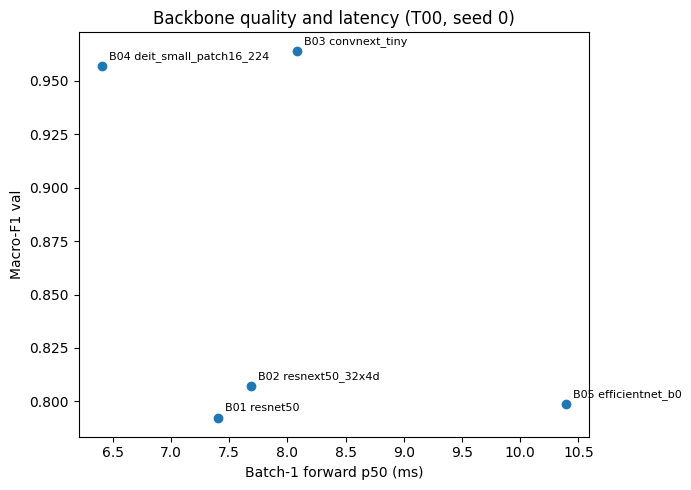

In [8]:
import json
from dataclasses import asdict
import timm
import benchmark
assert torch.cuda.is_available(), "Enable a Kaggle GPU before running five full experiments"
from train import Config, run, run_dir, SUBMISSION_DIR

# One model from every required family, with ConvNeXt and a lightweight model.
BACKBONES = [
    ("B01", "resnet50"),
    ("B02", "resnext50_32x4d"),
    ("B03", "convnext_tiny"),
    ("B04", "deit_small_patch16_224"),
    ("B05", "efficientnet_b0"),
]
SEED = 0
results_path = SUBMISSION_DIR / "results.xlsx"
rows = []

for exp_id, backbone in BACKBONES:
    cfg = Config(
        exp_id=exp_id, backbone=backbone, seed=SEED,
        images_dir=str(IMAGES_DIR), labels_dir=str(LABELS_DIR),
        save_test_predictions=False,
    )
    folder = run_dir(cfg)
    summary_path = folder / "summary.json"
    if summary_path.exists() and (folder / "best.pt").exists():
        saved_cfg = json.loads((folder / "config.json").read_text(encoding="utf-8"))
        if saved_cfg != asdict(cfg):
            raise ValueError(f"{exp_id}: saved configuration differs from T00; use a new exp_id")
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        print(f"{exp_id}: using completed training log")
    else:
        summary = run(cfg)

    latency_path = folder / "latency_batch1.json"
    gpu_name = torch.cuda.get_device_name(0)
    cached_latency = (json.loads(latency_path.read_text(encoding="utf-8"))
                      if latency_path.exists() else None)
    if (cached_latency and cached_latency.get("gpu") == gpu_name and
        cached_latency.get("img_size") == cfg.img_size and
        cached_latency.get("dtype") == "amp" and
        latency_path.stat().st_mtime >= (folder / "best.pt").stat().st_mtime):
        latency = cached_latency
    else:
        device_name = "cuda" if torch.cuda.is_available() else "cpu"
        restored = model.build_model(backbone, pretrained=False, init="scratch",
                                     drop_rate=cfg.drop_rate)
        state = torch.load(folder / "best.pt", map_location="cpu", weights_only=False)
        model.load_checkpoint_state(restored, state["state_dict"])
        latency = benchmark.latency_report(
            restored, batch_size=1, img_size=cfg.img_size,
            dtype="amp" if device_name == "cuda" else "fp32",
            device=device_name, warmup=10, iters=50,
        )
        latency_path.write_text(json.dumps(latency, indent=2), encoding="utf-8")
        del restored
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    row = {
        "exp_id": exp_id,
        "backbone": backbone,
        "weight_tag": summary["weight_tag"],
        "timm_version": timm.__version__,
        "params_m": summary["params_m"],
        "gmacs_thop": summary["gmacs"],
        "img_size": cfg.img_size,
        "epochs": cfg.epochs,
        "seed": cfg.seed,
        "macro_f1_val": summary["macro_f1_val"],
        "top1_val": summary["top1_val"],
        "train_seconds_per_epoch": summary["train_seconds_per_epoch"],
        "latency_batch1_p50_ms": latency["p50"],
        "latency_batch1_p95_ms": latency["p95"],
        "latency_dtype": latency["dtype"],
        "latency_device": latency["gpu"],
        "curve": str(SUBMISSION_DIR / "curves" /
                     f"{exp_id}_{backbone}_seed{SEED}.png"),
        "note": "T00 common recipe; one seed; val only",
    }
    rows.append(row)
    frame = pd.DataFrame(rows)
    if results_path.exists():
        with pd.ExcelWriter(results_path, engine="openpyxl", mode="a",
                            if_sheet_exists="replace") as writer:
            frame.to_excel(writer, sheet_name="Backbones", index=False)
    else:
        with pd.ExcelWriter(results_path, engine="openpyxl") as writer:
            frame.to_excel(writer, sheet_name="Backbones", index=False)
    display(frame.tail(1))

backbone_results = pd.DataFrame(rows).sort_values("macro_f1_val", ascending=False)
display(backbone_results)
print("Best val macro-F1:", backbone_results.iloc[0][["exp_id", "backbone", "macro_f1_val"]].to_dict())
fastest = backbone_results.sort_values("latency_batch1_p50_ms").iloc[0]
print("Lowest batch-1 latency:", fastest[["exp_id", "backbone", "latency_batch1_p50_ms"]].to_dict())
if backbone_results["gmacs_thop"].isna().any():
    print("Some GMAC measurements are unavailable; inspect each run log and THOP support.")
print("Comparison uses one seed. Choose 1–2 backbones after examining both F1 and latency.")
pareto = backbone_results.loc[
    [not any((other["macro_f1_val"] >= item["macro_f1_val"] and
              other["latency_batch1_p50_ms"] <= item["latency_batch1_p50_ms"] and
              (other["macro_f1_val"] > item["macro_f1_val"] or
               other["latency_batch1_p50_ms"] < item["latency_batch1_p50_ms"]))
             for _, other in backbone_results.iterrows())
     for _, item in backbone_results.iterrows()]
]
print("Models on the F1/latency Pareto frontier:")
display(pareto[["exp_id", "backbone", "macro_f1_val", "latency_batch1_p50_ms"]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(backbone_results["latency_batch1_p50_ms"], backbone_results["macro_f1_val"])
for _, item in backbone_results.iterrows():
    ax.annotate(item["exp_id"] + " " + item["backbone"],
                (item["latency_batch1_p50_ms"], item["macro_f1_val"]), xytext=(5, 5),
                textcoords="offset points", fontsize=8)
ax.set(xlabel="Batch-1 forward p50 (ms)", ylabel="Macro-F1 val",
       title="Backbone quality and latency (T00, seed 0)")
fig.tight_layout()
tradeoff_path = SUBMISSION_DIR / "curves" / "backbone_tradeoff.png"
tradeoff_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(tradeoff_path, dpi=160)
plt.show()

## Bước 2 — Công thức huấn luyện

Chọn backbone từ sheet Backbones sau khi xem kết quả Bước 1. T00 là công thức nền. T01–T06 thay đúng một trục A, B hoặc C; T07 kết hợp biến thể tốt nhất đã thử ở B và C. Mỗi cấu hình giữ nguyên fold, seed và số epoch. Kết quả vòng sàng chỉ có một seed, nên không kết luận từ chênh lệch nhỏ.

In [9]:
import workflow
SELECTED_BACKBONE = str(backbone_results.iloc[0]["backbone"])  # Edit after reviewing Step 1.
print("Backbone chosen from val:", SELECTED_BACKBONE)
training_results = workflow.run_ablation(SELECTED_BACKBONE, IMAGES_DIR, LABELS_DIR, seed=0)
display(training_results.sort_values("macro_f1_val", ascending=False))
selected_training = workflow.best_training_config(training_results)
print("Best training recipe on val:", selected_training.exp_id)
print("Review Training sheet, rare-class F1 and one-seed uncertainty before accepting this choice.")

Backbone chosen from val: convnext_tiny
Split audit: {'counts': {'train': 10501, 'val': 3501, 'test': 3507}, 'ratios': {'train': 0.5997487006682277, 'val': 0.19995430921240506, 'test': 0.2002969901193672}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union_count': 17509, 'missing_images': 0}


/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


T00 seed=0 epoch=1: {'epoch': 1, 'train_loss': 0.661751918085828, 'lr': 0.0001, 'val_loss': 0.4402255812259239, 'macro_f1_val': 0.8204205857176231, 'top1_val': 0.8474721508140531, 'train_seconds': 57.16149724600018, 'epoch_seconds': 74.37353082300069}
T00 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.20690091875404482, 'lr': 9.797464868072488e-05, 'val_loss': 0.17898904286395206, 'macro_f1_val': 0.927964926060733, 'top1_val': 0.9463010568409026, 'train_seconds': 54.24583419599912, 'epoch_seconds': 72.17157437999958}
T00 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.1346957404393612, 'lr': 9.206267664155907e-05, 'val_loss': 0.1874227039696863, 'macro_f1_val': 0.9303297264568227, 'top1_val': 0.9414453013424736, 'train_seconds': 53.57732996199957, 'epoch_seconds': 71.39455079100026}
T00 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.0704507826395878, 'lr': 8.274303669726426e-05, 'val_loss': 0.1705478209064743, 'macro_f1_val': 0.9316690675938621, 'top1_val': 0.9465866895172808, 'train_seconds'

/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


T01 seed=0 epoch=1: {'epoch': 1, 'train_loss': 1.1842462206032218, 'lr': 0.001, 'val_loss': 0.6578566894228886, 'macro_f1_val': 0.7403702822684024, 'top1_val': 0.7923450442730648, 'train_seconds': 27.32801624000058, 'epoch_seconds': 46.62147481300053}
T01 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.5112238915228262, 'lr': 0.0009797464868072487, 'val_loss': 0.4929660276255244, 'macro_f1_val': 0.7978947611112549, 'top1_val': 0.8423307626392459, 'train_seconds': 26.954903050000212, 'epoch_seconds': 43.92245012500007}
T01 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.40438373068847305, 'lr': 0.0009206267664155906, 'val_loss': 0.4528932563409367, 'macro_f1_val': 0.8141149464710474, 'top1_val': 0.853756069694373, 'train_seconds': 26.86081782600013, 'epoch_seconds': 45.089629401999446}
T01 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.35279723429461807, 'lr': 0.0008274303669726426, 'val_loss': 0.41999914916165726, 'macro_f1_val': 0.8290455762457295, 'top1_val': 0.8637532133676092, 'train_secon

...

T06 seed=0 epoch=1: {'epoch': 1, 'train_loss': 0.4128613722306199, 'lr': 0.0001, 'val_loss': 0.1448129677144298, 'macro_f1_val': 0.8704868178413424, 'top1_val': 0.8966009711510997, 'train_seconds': 56.90511643299942, 'epoch_seconds': 73.91832917099964}
T06 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.10940485999624176, 'lr': 9.797464868072488e-05, 'val_loss': 0.17385120679653907, 'macro_f1_val': 0.8627646986357036, 'top1_val': 0.887460725506998, 'train_seconds': 53.47345256600056, 'epoch_seconds': 71.3665080130013}
T06 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.06285557230627846, 'lr': 9.206267664155907e-05, 'val_loss': 0.10702426918436207, 'macro_f1_val': 0.9113557895912776, 'top1_val': 0.9291630962582119, 'train_seconds': 53.28607104499861, 'epoch_seconds': 70.77879122499871}
T06 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.0324361499699923, 'lr': 8.274303669726426e-05, 'val_loss': 0.08986024158668668, 'macro_f1_val': 0.9272979156689962, 'top1_val': 0.9420165666952299, 'train_secon

/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


T07 seed=0 epoch=1: {'epoch': 1, 'train_loss': 1.3307490196169875, 'lr': 0.0001, 'val_loss': 0.7450275753300996, 'macro_f1_val': 0.8633299636694081, 'top1_val': 0.8966009711510997, 'train_seconds': 57.24821626599987, 'epoch_seconds': 74.42243484299979}
T07 seed=0 epoch=2: {'epoch': 2, 'train_loss': 1.0319857172122815, 'lr': 9.797464868072488e-05, 'val_loss': 0.6657667999368366, 'macro_f1_val': 0.9009006471506265, 'top1_val': 0.9271636675235647, 'train_seconds': 54.61803406999934, 'epoch_seconds': 72.54753685899959}
T07 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.9618076802026935, 'lr': 9.206267664155907e-05, 'val_loss': 0.6271841728969902, 'macro_f1_val': 0.9394251211539262, 'top1_val': 0.9520137103684662, 'train_seconds': 54.752542933998484, 'epoch_seconds': 72.27883042399844}
T07 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.915325097557975, 'lr': 8.274303669726426e-05, 'val_loss': 0.6093632317685768, 'macro_f1_val': 0.9369220524424028, 'top1_val': 0.9480148528991716, 'train_seconds'

,exp_id,backbone,axis,difference_from_T00,seed,macro_f1_val,top1_val,delta_vs_T00,f1_chinee_apple_val,f1_snake_weed_val,note
4,T04,convnext_tiny,B_aug,"{""mix"": ""cutmix""}",0,0.969921,0.977149,0.005834,0.937355,0.924205,CutMix alpha=1; one screening seed
7,T07,convnext_tiny,B_plus_C,"{""mix"": ""cutmix"", ""loss"": ""ls"", ""label_smoothi...",0,0.969449,0.976864,0.005362,0.934884,0.924939,Combined best tested B (T04) and C (T05); one ...
5,T05,convnext_tiny,C_loss,"{""loss"": ""ls"", ""label_smoothing"": 0.1}",0,0.965819,0.973436,0.001731,0.925581,0.920000,label smoothing 0.1; one screening seed
0,T00,convnext_tiny,baseline,{},0,0.964087,0.972008,0.000000,0.925234,0.919315,T00 recipe; one screening seed
6,T06,convnext_tiny,C_loss,"{""loss"": ""focal""}",0,0.960677,0.969437,-0.003410,0.926267,0.914425,focal gamma=2; one screening seed
3,T03,convnext_tiny,B_aug,"{""aug"": ""color""}",0,0.958044,0.966581,-0.006043,0.915493,0.918519,color jitter; one screening seed
1,T01,convnext_tiny,A_init,"{""init"": ""frozen""}",0,0.851227,0.882034,-0.112861,0.816514,0.767726,frozen backbone; one screening seed
2,T02,convnext_tiny,A_init,"{""init"": ""scratch""}",0,0.338632,0.557269,-0.625455,0.220000,0.343949,train from scratch; one screening seed


Best training recipe on val: T04
Review Training sheet, rare-class F1 and one-seed uncertainty before accepting this choice.


## Bước 3 — Suy luận và độ trễ

Dùng checkpoint tốt nhất từ Bước 2. So sánh I00 một view với I01 lật ngang, I02 năm crop, I03 gộp logit và I07 temperature scaling trên **val**. Mỗi phương pháp được đo batch 1 và batch 16: 10 lần warmup, 50 lần đo, đồng bộ CUDA, FP32; phép biến đổi trên GPU được tính, đọc ảnh từ đĩa không được tính.

In [10]:
inference_results, recommendation = workflow.compare_inference(selected_training, large_batch=16)
display(inference_results.sort_values("macro_f1_val", ascending=False))
print("Val-only suggestion:", recommendation)
FINAL_METHOD = recommendation["method"]       # I00, I01, I02 or I03; edit after reviewing latency.
USE_CALIBRATION = recommendation["calibrate"] # Refit one T on val for each final seed.
print("Inspect Inference and Latency sheets before fixing the final method.")

,exp_id,method,checkpoint,k,macro_f1_val,top1_val,ece_val,p50_ms,p95_ms,p99_ms,images_per_s,relative_cost_vs_I00
2,I02,"five resized crops, probability mean",/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,5,0.976573,0.981720,0.006721,30.234089,31.299857,32.048741,33.075248,4.836469
3,I03,"horizontal flip, logit mean",/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,2,0.971329,0.978292,0.004638,12.281721,13.370225,13.877644,81.421814,1.964675
1,I01,"horizontal flip, probability mean",/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,2,0.971329,0.978292,0.004713,12.803832,13.632803,13.699348,78.101621,2.048196
0,I00,single center crop,/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,1,0.969921,0.977149,0.004314,6.251273,9.419946,9.451402,159.967418,1.000000
4,I07,"temperature scaling, T=1.0081",/kaggle/working/K4-DAY02-TongTranTienDung-2A20...,1,0.969921,0.977149,0.003873,6.140363,6.465470,7.097901,162.856808,0.982258


Val-only suggestion: {'source_exp_id': 'T04', 'method': 'I02', 'calibrate': True, 'val_ece_before': 0.0067208374067566565, 'val_ece_after': 0.0025772929463271275, 'seed': 0}
Inspect Inference and Latency sheets before fixing the final method.


## Bước 4 — Chốt trên val, sau đó mới đọc test

Xem bảng Backbones, Training và Inference trước khi bật hai cờ bên dưới. Bước huấn luyện chung kết chạy F01 và mốc T00 cùng seed 0, 1, 2, không gộp val. Cờ đọc test mặc định tắt. Mỗi file test được ghi đúng một lần; nếu quá trình dừng giữa chừng sau khi đã bắt đầu đọc test, hãy kiểm tra dấu `test_started.json` thay vì chạy lại tự động.

In [13]:
from dataclasses import asdict
from dataclasses import replace
from eval import read_pred, check_against_csv

FINAL_RECIPE = selected_training   # Edit only using val evidence before enabling final training.
FINAL_METHOD = FINAL_METHOD         # Chosen from val in Step 3.
USE_CALIBRATION = USE_CALIBRATION
RUN_FINAL_TRAINING = True          # Set True after reviewing all val results.
RUN_FINAL_TEST = False              # Set True only after training and fixing the configuration.
SEEDS = (0, 1, 2)
selection_file = SUBMISSION_DIR / "final_selection.json"
selection = {"recipe": asdict(FINAL_RECIPE), "method": FINAL_METHOD,
             "calibrate": USE_CALIBRATION, "seeds": list(SEEDS)}

if RUN_FINAL_TRAINING:
    if selection_file.exists():
        previous = json.loads(selection_file.read_text(encoding="utf-8"))
        if previous != selection:
            raise ValueError("Final selection changed. Inspect the saved selection before proceeding.")
    else:
        selection_file.write_text(json.dumps(selection, indent=2), encoding="utf-8")
    final_training = workflow.train_final_pair(FINAL_RECIPE, SEEDS)
    display(final_training)
else:
    print("Final training is paused. Review val results, then set RUN_FINAL_TRAINING=True.")

if RUN_FINAL_TEST:
    if not RUN_FINAL_TRAINING:
        raise ValueError("Train and lock the final configuration before reading test")
    for seed in SEEDS:
        final_cfg = replace(FINAL_RECIPE, exp_id="F01", seed=seed,
                            save_test_predictions=False)
        baseline_cfg = train.Config(exp_id="T00", backbone=FINAL_RECIPE.backbone,
                                    seed=seed, images_dir=str(IMAGES_DIR),
                                    labels_dir=str(LABELS_DIR),
                                    save_test_predictions=False)
        print("Test:", workflow.predict_test_once(final_cfg, FINAL_METHOD, USE_CALIBRATION))
        print("Baseline test:", workflow.predict_test_once(baseline_cfg, "I00", False))
else:
    print("Test remains unopened. Set RUN_FINAL_TEST=True only after the val-based choice is fixed.")

Split audit: {'counts': {'train': 10501, 'val': 3501, 'test': 3507}, 'ratios': {'train': 0.5997487006682277, 'val': 0.19995430921240506, 'test': 0.2002969901193672}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union_count': 17509, 'missing_images': 0}


/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


F01 seed=0 epoch=1: {'epoch': 1, 'train_loss': 1.1068626887551167, 'lr': 0.0001, 'val_loss': 0.38431786454871397, 'macro_f1_val': 0.8396154611739897, 'top1_val': 0.8800342759211653, 'train_seconds': 57.67424060899975, 'epoch_seconds': 74.89052448300026}
F01 seed=0 epoch=2: {'epoch': 2, 'train_loss': 0.7314523485739056, 'lr': 9.797464868072488e-05, 'val_loss': 0.2339271652259271, 'macro_f1_val': 0.9033978828412947, 'top1_val': 0.9271636675235647, 'train_seconds': 55.96072443699995, 'epoch_seconds': 73.46584116000122}
F01 seed=0 epoch=3: {'epoch': 3, 'train_loss': 0.620623515191965, 'lr': 9.206267664155907e-05, 'val_loss': 0.2172768642326247, 'macro_f1_val': 0.9191672999051771, 'top1_val': 0.9351613824621536, 'train_seconds': 54.4853994820005, 'epoch_seconds': 72.38701226200101}
F01 seed=0 epoch=4: {'epoch': 4, 'train_loss': 0.5688590013944521, 'lr': 8.274303669726426e-05, 'val_loss': 0.15294173876367886, 'macro_f1_val': 0.9436713075162859, 'top1_val': 0.9514424450157098, 'train_seconds'

/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


T00 seed=1 epoch=1: {'epoch': 1, 'train_loss': 0.7120793696220328, 'lr': 0.0001, 'val_loss': 0.40222865706578353, 'macro_f1_val': 0.8283079668580104, 'top1_val': 0.8623250499857184, 'train_seconds': 57.163953496999966, 'epoch_seconds': 74.21500089099936}
T00 seed=1 epoch=2: {'epoch': 2, 'train_loss': 0.2299846891291076, 'lr': 9.797464868072488e-05, 'val_loss': 0.24509385517582624, 'macro_f1_val': 0.8978352551064712, 'top1_val': 0.9240217080834048, 'train_seconds': 54.29699410000103, 'epoch_seconds': 72.04549525100083}
T00 seed=1 epoch=3: {'epoch': 3, 'train_loss': 0.11298210896188166, 'lr': 9.206267664155907e-05, 'val_loss': 0.26183028015212584, 'macro_f1_val': 0.8925368142459743, 'top1_val': 0.9140245644101685, 'train_seconds': 53.6592440229997, 'epoch_seconds': 71.28863656800058}
T00 seed=1 epoch=4: {'epoch': 4, 'train_loss': 0.09483051376144697, 'lr': 8.274303669726426e-05, 'val_loss': 0.21190159344155596, 'macro_f1_val': 0.9125261724366927, 'top1_val': 0.9320194230219937, 'train_se

...

T00 seed=2 epoch=1: {'epoch': 1, 'train_loss': 0.7100040733178214, 'lr': 0.0001, 'val_loss': 0.31204670573159377, 'macro_f1_val': 0.8686999173249963, 'top1_val': 0.897172236503856, 'train_seconds': 57.036358679999466, 'epoch_seconds': 74.09776407400022}
T00 seed=2 epoch=2: {'epoch': 2, 'train_loss': 0.20282333030751565, 'lr': 9.797464868072488e-05, 'val_loss': 0.26007938842983186, 'macro_f1_val': 0.8899715802588454, 'top1_val': 0.9120251356755212, 'train_seconds': 54.092081463000795, 'epoch_seconds': 71.93109982699934}
T00 seed=2 epoch=3: {'epoch': 3, 'train_loss': 0.11884883348262165, 'lr': 9.206267664155907e-05, 'val_loss': 0.14721036763897422, 'macro_f1_val': 0.9396564598402468, 'top1_val': 0.951728077692088, 'train_seconds': 53.59812020899881, 'epoch_seconds': 71.07340893199944}
T00 seed=2 epoch=4: {'epoch': 4, 'train_loss': 0.08291163187610304, 'lr': 8.274303669726426e-05, 'val_loss': 0.32000685232736426, 'macro_f1_val': 0.8847715596021852, 'top1_val': 0.905169951442445, 'train_se

/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/code/train.py:189: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()  # per iteration, after optimizer.step


F01 seed=2 epoch=1: {'epoch': 1, 'train_loss': 1.1853091556851456, 'lr': 0.0001, 'val_loss': 0.30733451518764565, 'macro_f1_val': 0.9067943190939126, 'top1_val': 0.9251642387889174, 'train_seconds': 57.258784851997916, 'epoch_seconds': 74.54219057499722}
F01 seed=2 epoch=2: {'epoch': 2, 'train_loss': 0.707060434651084, 'lr': 9.797464868072488e-05, 'val_loss': 0.25116101997779183, 'macro_f1_val': 0.9048490345537404, 'top1_val': 0.9234504427306484, 'train_seconds': 54.60727247799878, 'epoch_seconds': 72.45682144700186}
F01 seed=2 epoch=3: {'epoch': 3, 'train_loss': 0.6171720203284811, 'lr': 9.206267664155907e-05, 'val_loss': 0.18917239895976296, 'macro_f1_val': 0.9282879275108734, 'top1_val': 0.9457297914881463, 'train_seconds': 55.00586327899873, 'epoch_seconds': 72.71061456499956}
F01 seed=2 epoch=4: {'epoch': 4, 'train_loss': 0.5646363865902148, 'lr': 8.274303669726426e-05, 'val_loss': 0.15220292857445095, 'macro_f1_val': 0.9481126530627084, 'top1_val': 0.9585832619251642, 'train_seco

,exp_id,seed,backbone,macro_f1_val,top1_val,best_epoch
0,T00,0,convnext_tiny,0.964087,0.972008,11
1,F01,0,convnext_tiny,0.969921,0.977149,11
2,T00,1,convnext_tiny,0.968488,0.975436,9
3,F01,1,convnext_tiny,0.973020,0.979149,12
4,T00,2,convnext_tiny,0.966752,0.973722,11
5,F01,2,convnext_tiny,0.971366,0.977721,11


Test remains unopened. Set RUN_FINAL_TEST=True only after the val-based choice is fixed.


In [14]:
from dataclasses import asdict
from dataclasses import replace
from eval import read_pred, check_against_csv

FINAL_RECIPE = selected_training   # Edit only using val evidence before enabling final training.
FINAL_METHOD = FINAL_METHOD         # Chosen from val in Step 3.
USE_CALIBRATION = USE_CALIBRATION
RUN_FINAL_TRAINING = True          # Set True after reviewing all val results.
RUN_FINAL_TEST = True              # Set True only after training and fixing the configuration.
SEEDS = (0, 1, 2)
selection_file = SUBMISSION_DIR / "final_selection.json"
selection = {"recipe": asdict(FINAL_RECIPE), "method": FINAL_METHOD,
             "calibrate": USE_CALIBRATION, "seeds": list(SEEDS)}

if RUN_FINAL_TRAINING:
    if selection_file.exists():
        previous = json.loads(selection_file.read_text(encoding="utf-8"))
        if previous != selection:
            raise ValueError("Final selection changed. Inspect the saved selection before proceeding.")
    else:
        selection_file.write_text(json.dumps(selection, indent=2), encoding="utf-8")
    final_training = workflow.train_final_pair(FINAL_RECIPE, SEEDS)
    display(final_training)
else:
    print("Final training is paused. Review val results, then set RUN_FINAL_TRAINING=True.")

if RUN_FINAL_TEST:
    if not RUN_FINAL_TRAINING:
        raise ValueError("Train and lock the final configuration before reading test")
    for seed in SEEDS:
        final_cfg = replace(FINAL_RECIPE, exp_id="F01", seed=seed,
                            save_test_predictions=False)
        baseline_cfg = train.Config(exp_id="T00", backbone=FINAL_RECIPE.backbone,
                                    seed=seed, images_dir=str(IMAGES_DIR),
                                    labels_dir=str(LABELS_DIR),
                                    save_test_predictions=False)
        print("Test:", workflow.predict_test_once(final_cfg, FINAL_METHOD, USE_CALIBRATION))
        print("Baseline test:", workflow.predict_test_once(baseline_cfg, "I00", False))
else:
    print("Test remains unopened. Set RUN_FINAL_TEST=True only after the val-based choice is fixed.")

,exp_id,seed,backbone,macro_f1_val,top1_val,best_epoch
0,T00,0,convnext_tiny,0.964087,0.972008,11
1,F01,0,convnext_tiny,0.969921,0.977149,11
2,T00,1,convnext_tiny,0.968488,0.975436,9
3,F01,1,convnext_tiny,0.973020,0.979149,12
4,T00,2,convnext_tiny,0.966752,0.973722,11
5,F01,2,convnext_tiny,0.971366,0.977721,11


Test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed0_test.csv
Baseline test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed0_test.csv
Test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed1_test.csv
Baseline test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed1_test.csv
Test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed2_test.csv
Baseline test: /kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed2_test.csv


In [15]:
# Recompute official metrics from saved prediction files only; no model or test loader is run here.
import subprocess
pred_dir = SUBMISSION_DIR / "predictions"
eval_out = SUBMISSION_DIR / "eval_out"
for exp_id in ("F01", "T00"):
    files = [pred_dir / f"{exp_id}_seed{seed}_test.csv" for seed in SEEDS]
    if not all(path.is_file() for path in files):
        raise FileNotFoundError(f"Finish Step 4 before scoring {exp_id}: {files}")
    command = [sys.executable, str(REPO_DIR / "eval.py"), "score",
               "--pred", *map(str, files),
               "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
               "--tag", exp_id, "--out", str(eval_out)]
    labels_csv = LABELS_DIR / "labels.csv"
    if labels_csv.exists():
        command += ["--labels", str(labels_csv)]
    subprocess.run(command, check=True)

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9822 ± 0.0002 |
| macro-F1 | 0.9776 ± 0.0002 |
| balanced accuracy | 0.9755 ± 0.0005 |
| ECE (15 bin) | 0.0043 ± 0.0010 |
| NLL | 0.0611 ± 0.0032 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.991 ± 0.000 | 0.937 ± 0.009 | 0.963 ± 0.005 | 226 |
| Lantana | 0.994 ± 0.003 | 0.972 ± 0.005 | 0.983 ± 0.004 | 213 |
| Parkinsonia | 0.978 ± 0.003 | 0.995 ± 0.000 | 0.986 ± 0.001 | 207 |
| Parthenium | 0.995 ± 0.005 | 0.979 ± 0.003 | 0.987 ± 0.004 | 205 |
| Prickly acacia | 0.957 ± 0.005 | 0.977 ± 0.008 | 0.967 ± 0.004 | 213 |
| Rubber vine | 0.988 ± 0.003 | 0.974 ± 0.003 | 0.981 ± 0.003 | 202 |
| Siam weed | 0.988 ± 0.007 | 0.992 ± 0.003 | 0.990 ± 0.005 | 215 |
| Snake weed | 0.944 ± 0.005 | 0.964 ± 0.007 | 0.954 ± 0.003 | 204 |
| Negative | 0.985 ± 0.001 | 0.990 ± 0.001 | 0.988 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/K4-DAY02-TongTranTienDung-2A2026

In [16]:
# Official rubric check. This reads saved CSVs; it never calls the model.
command = [sys.executable, str(REPO_DIR / "eval.py"), "grade",
           "--final", *[str(pred_dir / f"F01_seed{seed}_test.csv") for seed in SEEDS],
           "--baseline", *[str(pred_dir / f"T00_seed{seed}_test.csv") for seed in SEEDS],
           "--final-val", *[str(pred_dir / f"F01_seed{seed}_val.csv") for seed in SEEDS],
           "--test-csv", str(LABELS_DIR / "test_subset0.csv"),
           "--val-csv", str(LABELS_DIR / "val_subset0.csv"),
           "--out", str(eval_out)]
if USE_CALIBRATION:
    command += ["--uncal", *[str(pred_dir / f"F01uncal_seed{seed}_test.csv") for seed in SEEDS]]
if (LABELS_DIR / "labels.csv").exists():
    command += ["--labels", str(LABELS_DIR / "labels.csv")]
subprocess.run(command, check=True)

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 98.22% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9776, mốc 0.9696, Δ=+0.0080, s=0.0016 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 93.7% (mốc 88.5%), Snake Weed 96.4% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0071, sau 0.0043 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9773, test 0.9776, chênh 0.0002 |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 17 / 18** (phần I tối đa 20).
Chưa chấm được: I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


CompletedProcess(args=['/usr/bin/python3', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/eval.py', 'grade', '--final', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed0_test.csv', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed1_test.csv', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/F01_seed2_test.csv', '--baseline', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed0_test.csv', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed1_test.csv', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/predictions/T00_seed2_test.csv', '--final-val', '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602

## Bước 5 — Bảng kết quả và báo cáo

Sau khi eval.py xác nhận các file dự đoán, tạo đủ bảy sheet trong `results.xlsx`, ma trận nhầm lẫn, danh sách ảnh dự đoán sai và bản thảo `report.md` từ số liệu thật. Đọc lại báo cáo và bổ sung nhận xét định tính, phần cứng, phiên bản thư viện và link Kaggle notebook.

In [17]:
artifact_summary = workflow.make_final_artifacts(FINAL_RECIPE, FINAL_METHOD,
                                                   USE_CALIBRATION, SEEDS)
display(pd.read_excel(SUBMISSION_DIR / "results.xlsx", sheet_name="Summary"))
display(pd.read_excel(SUBMISSION_DIR / "results.xlsx", sheet_name="Final"))
print("Created from real predictions:", artifact_summary)
print("Review report.md and add data interpretation and the Kaggle notebook link.")

,stage,exp_id,macro_f1_val,latency_batch1_p50_ms,backbone_or_method
0,Inference,I02,0.976573,30.234089,"five resized crops, probability mean"
1,Inference,I01,0.971329,12.803832,"horizontal flip, probability mean"
2,Inference,I03,0.971329,12.281721,"horizontal flip, logit mean"
3,Inference,I07,0.969921,6.140363,"temperature scaling, T=1.0081"
4,Inference,I00,0.969921,6.251273,single center crop
5,Training,T04,0.969921,NaN,convnext_tiny
6,Training,T07,0.969449,NaN,convnext_tiny
7,Training,T05,0.965819,NaN,convnext_tiny
8,Backbones,B03,0.964087,8.083822,convnext_tiny
9,Training,T00,0.964087,NaN,convnext_tiny


,exp_id,configuration,seed,macro_f1_val,macro_f1_test,top1_test,ece_test,mean_std
0,T00,T00 + I00,0,0.964087,0.968170,0.974622,0.016625,NaN
1,T00,T00 + I00,1,0.968488,0.971309,0.977474,0.013401,NaN
2,T00,T00 + I00,2,0.966752,0.969267,0.975763,0.015044,NaN
3,T00,summary,mean ± std,0.966443,0.969582,0.975953,0.015023,0.9696 ± 0.0016
4,F01,convnext_tiny + T04 recipe + I02 + calibrated,0,0.976573,0.977507,0.982321,0.005447,NaN
5,F01,convnext_tiny + T04 recipe + I02 + calibrated,1,0.979284,0.977792,0.982036,0.003588,NaN
6,F01,convnext_tiny + T04 recipe + I02 + calibrated,2,0.976059,0.977354,0.982321,0.003836,NaN
7,F01,summary,mean ± std,0.977305,0.977551,0.982226,0.004290,0.9776 ± 0.0002


Created from real predictions: {'final_macro_f1_mean': 0.9775512028966366, 'baseline_macro_f1_mean': 0.9695821230367972, 'delta': 0.007969079859839301, 'results': '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/results.xlsx', 'report': '/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/submissions/2A202602791_Tong_Tran_Tien_Dung/report.md'}
Review report.md and add data interpretation and the Kaggle notebook link.


In [18]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from IPython.display import FileLink, display
import os

submission = Path(
    "/kaggle/working/K4-DAY02-TongTranTienDung-2A202602791/"
    "submissions/2A202602791_Tong_Tran_Tien_Dung"
)
zip_path = Path("/kaggle/working/DeepWeeds_ket_qua.zip")

assert submission.is_dir(), f"Không tìm thấy thư mục: {submission}"

excluded_dirs = {"__pycache__", ".ipynb_checkpoints"}
excluded_files = {"best.pt"}  # Checkpoint lớn; giữ lại trên Kaggle nếu còn cần

count = 0
with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as archive:
    for file in submission.rglob("*"):
        if not file.is_file():
            continue
        relative = file.relative_to(submission)
        if any(part in excluded_dirs for part in relative.parts):
            continue
        if file.name in excluded_files:
            continue
        archive.write(file, arcname=Path(submission.name) / relative)
        count += 1

print(f"Đã đóng gói {count} file: {zip_path}")
print(f"Dung lượng: {zip_path.stat().st_size / 1024**2:.1f} MB")

os.chdir("/kaggle/working")
display(FileLink(zip_path.name))

Đã đóng gói 194 file: /kaggle/working/DeepWeeds_ket_qua.zip
Dung lượng: 9.0 MB


/kaggle/working/DeepWeeds_ket_qua.zip

In [19]:
from IPython.display import Javascript, display
import json

display(Javascript(f"""
setTimeout(() => {{
    const link = document.createElement("a");
    link.href = {json.dumps(zip_path.name)};
    link.download = {json.dumps(zip_path.name)};
    document.body.appendChild(link);
    link.click();
    link.remove();
}}, 1000);
"""))

<IPython.core.display.Javascript object>